# 03 - First prior: L2 / Tikhonov

Lecture section: 3.6-3.9  |  Spine term this tutorial changes: the prior $R(x)$

$$\hat{x} = \arg\min_x\ \underbrace{D(Ax, y)}_{\text{data fidelity}} + \underbrace{R(x)}_{\text{prior}}$$

So far the prior has been empty and our reconstructions were unusable: sparse-view CT
is ill-posed, so the tiny singular values of $A$ amplify noise without bound. The cure
is to *add a prior* $R(x)$ that penalizes wild solutions. The simplest possible choice
is the **quadratic (Tikhonov) prior** $R(x) = \tfrac{\lambda}{2}\lVert x \rVert^2$.

Because this prior is **quadratic**, the whole objective
$\tfrac12\lVert Ax-y\rVert^2 + \tfrac{\lambda}{2}\lVert x\rVert^2$ is quadratic and has a
**closed-form** minimizer - no iterative optimizer needed. Setting the gradient to zero
gives the *regularized normal equations*

$$(A^\top A + \lambda I)\,\hat{x} = A^\top y \quad\Longleftrightarrow\quad
  \hat{x} = (A^\top A + \lambda I)^{-1} A^\top y,$$

which we solve **directly** with a linear solver (deepinv's `physics.prox_l2`, a few
conjugate-gradient steps on this one linear system). That is why we do *not* reach for
proximal gradient descent here - PGD is the general iterative machinery we only *need* in
notebook 4, where the TV prior is non-smooth and has no closed form. The single knob
$\lambda$ controls a bias-variance trade-off: too small leaves noise, too large blurs
everything away.

In [1]:
import tutorial_common as tc
import deepinv as dinv

tc.set_seed()

deepinv 0.4.1 | torch 2.9.1 | device cpu


## The problem: the hard sparse-view case from notebook 2

We tackle the *same* explosive problem notebook 2 diagnosed: **20** projection angles and
Gaussian noise $\sigma=0.05$ - ill-posed enough that with no prior the pseudo-inverse blew
up. Choosing a harder operator here makes the bias-variance trade-off unmistakable: too
little regularization is visibly noisy, not just marginally worse. (Notebooks 4-5 use a
somewhat easier 40-angle version of the same operator.)

In [2]:
phys = tc.ct_physics(angles=20, sigma=0.05)   # fixed physics A (+ noise) = data fidelity D
x = tc.load_object(128)                          # ground-truth object x  (1,1,128,128)
y = phys(x)                                     # noisy sinogram y = A x + noise

# A naive linear baseline: filtered back-projection (no prior at all).
x_fbp = phys.fbp(y)
print(f"sinogram y shape : {tuple(y.shape)}")
print(f"FBP baseline     : PSNR {tc.psnr(x_fbp, x):.2f} dB  (no prior -> noisy)")

sinogram y shape : (1, 1, 182, 20)
FBP baseline     : PSNR 7.64 dB  (no prior -> noisy)


## Tikhonov as a direct linear solve

`physics.prox_l2(z, y, gamma)` returns $\arg\min_x \tfrac{\gamma}{2}\lVert Ax-y\rVert^2 +
\tfrac12\lVert x-z\rVert^2$. With $z=0$ and $\gamma = 1/\lambda$ this is *exactly* the
Tikhonov problem $\tfrac12\lVert Ax-y\rVert^2 + \tfrac{\lambda}{2}\lVert x\rVert^2$, i.e. it
solves the regularized normal equations $(A^\top A + \lambda I)\hat{x} = A^\top y$ directly.
One call = one reconstruction; no optimization loop, no stepsize to tune.

In [3]:
def tikhonov(lam):
    """Direct Tikhonov solve: (A^T A + lam I) x = A^T y  via physics.prox_l2 (z=0, gamma=1/lam)."""
    return phys.prox_l2(0.0, y, gamma=1.0 / float(lam), max_iter=150, tol=1e-6)

## Bias-variance sweep over $\lambda$

We scan $\lambda$ across a few orders of magnitude. Watch the PSNR rise as the prior starts
to suppress noise, peak, then fall as the prior over-smooths and erases the object. On this
hard 20-angle problem the too-small $\lambda$ is now clearly the *worst*, not a near-tie
with the best.

In [4]:
lambdas = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]   # too-small ... peak ... too-large
recons = {lam: tikhonov(lam) for lam in lambdas}
psnrs = {lam: tc.psnr(recons[lam], x) for lam in lambdas}

best_lam = max(psnrs, key=psnrs.get)
for lam in lambdas:
    flag = "  <- best" if lam == best_lam else ""
    print(f"lambda = {lam:<7g}  PSNR = {psnrs[lam]:5.2f} dB{flag}")
print(f"\nPeak at lambda = {best_lam:g}  ->  PSNR {psnrs[best_lam]:.2f} dB")

lambda = 0.001    PSNR = 14.20 dB
lambda = 0.003    PSNR = 15.31 dB
lambda = 0.01     PSNR = 16.48 dB
lambda = 0.03     PSNR = 16.90 dB  <- best
lambda = 0.1      PSNR = 15.97 dB
lambda = 0.3      PSNR = 14.77 dB

Peak at lambda = 0.03  ->  PSNR 16.90 dB


## Panel: too small | best | too large

Under-regularized (left) is still grainy from amplified noise; over-regularized (right)
is a featureless blur. The sweet spot in the middle is the best the *quadratic* prior can do.

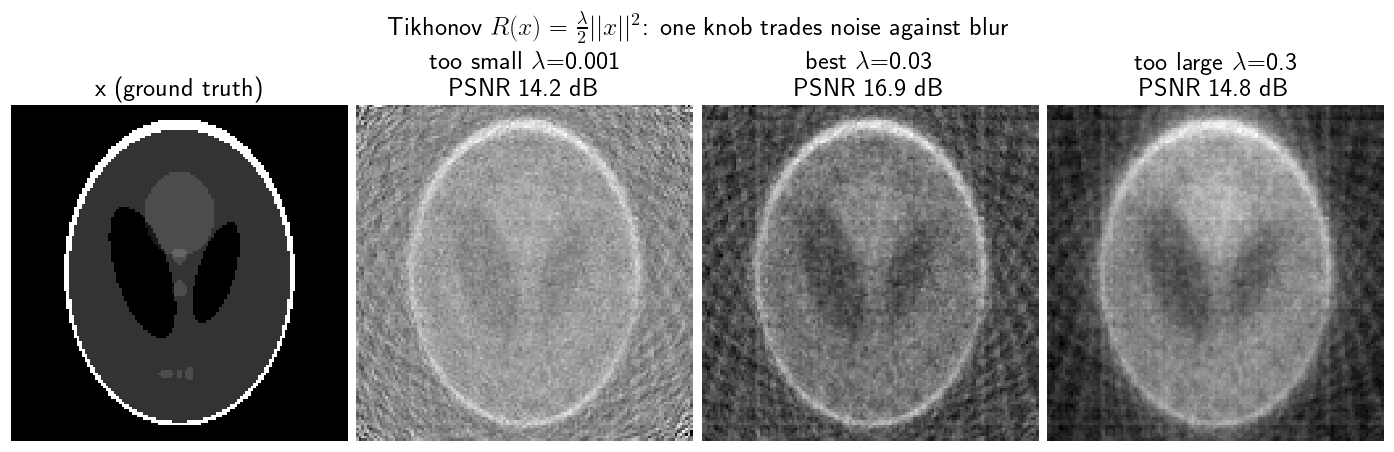

In [5]:
small_lam, large_lam = lambdas[0], lambdas[-1]
tc.show_images(
    [x, recons[small_lam], recons[best_lam], recons[large_lam]],
    titles=[
        "x (ground truth)",
        tc.title_psnr(f"too small $\\lambda$={small_lam:g}", recons[small_lam], x),
        tc.title_psnr(f"best $\\lambda$={best_lam:g}", recons[best_lam], x),
        tc.title_psnr(f"too large $\\lambda$={large_lam:g}", recons[large_lam], x),
    ],
    suptitle="Tikhonov $R(x)=\\frac{\\lambda}{2}||x||^2$: one knob trades noise against blur",
    figsize=(14, 4),   # wide enough that the per-panel titles don't collide
)

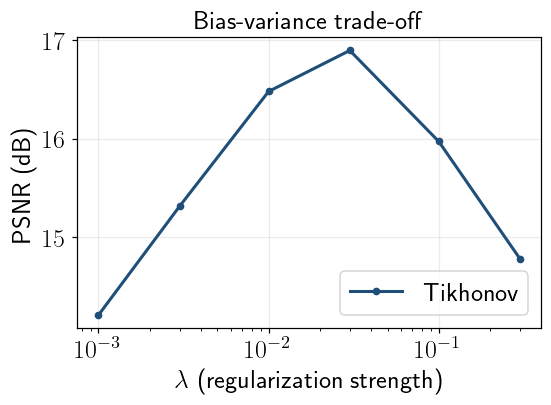

In [6]:
# PSNR-vs-lambda curve: the classic bias-variance trade-off, with a single peak.
tc.show_curves(
    {"Tikhonov": ([float(l) for l in lambdas], [psnrs[l] for l in lambdas])},
    xlabel="$\\lambda$  (regularization strength)",
    ylabel="PSNR (dB)",
    title="Bias-variance trade-off",
    logy=False,
    logx=True,
    markers=True,
)

## Why Tikhonov can never give sharp edges

Write $A = U\Sigma V^\top$ (the SVD from notebook 2). The Tikhonov solution has a
**closed form** -- it is *Wiener filtering* / *damped SVD inversion*:

$$\hat{x} = \sum_i \underbrace{\frac{\sigma_i}{\sigma_i^2 + \lambda}}_{\text{filtered } 1/\sigma_i}\,(u_i^\top y)\, v_i
  \quad\Longleftrightarrow\quad
  \text{each component is shrunk by } \frac{\sigma_i^2}{\sigma_i^2 + \lambda}.$$

- For **large** singular values ($\sigma_i^2 \gg \lambda$) the factor is $\approx 1$:
  well-measured, low-frequency content passes through untouched.
- For **small** singular values ($\sigma_i^2 \ll \lambda$) the factor is $\approx
  \sigma_i^2/\lambda \to 0$: the noise-amplifying directions are damped -- this is exactly
  the stabilization that fixes the ill-posedness from notebook 2.

But sharp **edges** live precisely in those small-singular-value (high-frequency)
directions. Tikhonov *throws them away*. A quadratic penalty inevitably smooths -- it
denoises but cannot draw a crisp boundary. That is the wall a smarter prior must break.

## Takeaway

A quadratic prior $R(x)=\tfrac{\lambda}{2}\lVert x\rVert^2$ stabilizes the ill-posed
small-singular-value directions and gives us *one knob* $\lambda$ trading noise against
blur -- but because it shrinks **every** component, it smears edges and can never be sharp.
Next we replace it with a prior that *prefers* edges: TV / sparsity.